<a href="{{ colab_base_laboratorios }}/Laboratorio_03_intuicion_estadistica_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Angulo Toro Santiago Andrés 1001154362

# Lab 3: Intuición estadística

## Model Selection and Train/Validation/Test Sets
[1] Reference http://cs229.stanford.edu/syllabus.html

Just because a learning algorithm fits a training set well, that does not mean it is a good hypothesis. It could over fit and as a result your predictions on the test set would be poor. The error of your hypothesis as measured on the data set with which you trained the parameters will be lower than the error on any other data set.
Given many models with different complexities (for example polynomial degree), we can use a systematic approach to identify the 'best' function. In order to choose the model of your hypothesis, you can test each degree of polynomial and look at the error result.

One way to break down our dataset into the three sets is:
Training set: 60%
Cross validation set: 20%
Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:
1. Optimize the parameters in Θ using the training set for each polynomial degree.
2. Find the polynomial degree d with the least error using the cross validation set.
3. Estimate the generalization error using the test set with J_{test}

This way, the degree of the polynomial d has not been trained using the test set.



## Para entregar


1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, validation_curve, learning_curve, GridSearchCV
from sklearn.svm import SVC

# 0. Generación del dataset base de la Sesión 3
X_raw, y_raw = make_blobs(n_samples=500, centers=2, cluster_std=1.8, random_state=42)

# Divisíón del dataset: 80% Entrenamiento + Validación Cruzada y 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42
)

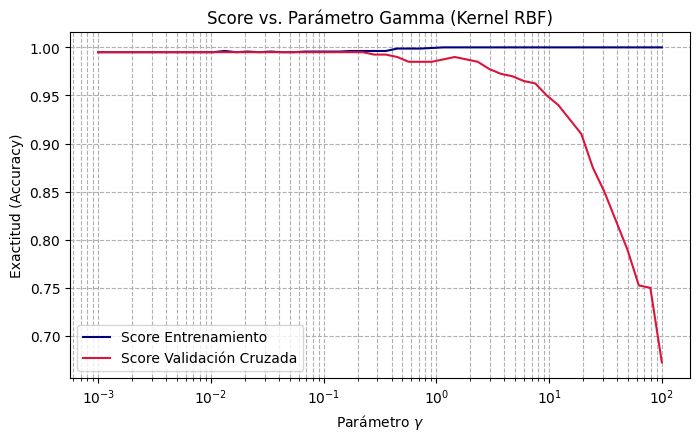

Mejor gamma: 0.0010 | Test Score: 1.0000


In [10]:
# Definición del rango de gamma
param_range = np.logspace(-3, 2, 50)

# Cálculo de scores de entrenamiento y validación cruzada
train_scores, val_scores = validation_curve(
    SVC(kernel='rbf', C=1.0),
    X_train_val, y_train_val,
    param_name="gamma",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

mean_train = np.mean(train_scores, axis=1)
mean_val = np.mean(val_scores, axis=1)

# Visualización de la curva de hiperparámetro
plt.figure(figsize=(8, 4.5))
plt.semilogx(param_range, mean_train, label="Score Entrenamiento", color="navy")
plt.semilogx(param_range, mean_val, label="Score Validación Cruzada", color="crimson")
plt.xlabel(r"Parámetro $\gamma$")
plt.ylabel("Exactitud (Accuracy)")
plt.title("Score vs. Parámetro Gamma (Kernel RBF)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Evaluación final en el conjunto de Test
best_gamma = param_range[np.argmax(mean_val)]
clf_opt = SVC(kernel='rbf', gamma=best_gamma, C=1.0).fit(X_train_val, y_train_val)
print(f"Mejor gamma: {best_gamma:.4f} | Test Score: {clf_opt.score(X_test, y_test):.4f}")

La mejor solución la presenta un valor intermedio del parámetro $\gamma$ (específicamente alrededor de $\gamma \approx 0.1$ a $1.0$, correspondiente al punto donde se maximiza el score en la curva de validación cruzada).  Este valor es óptimo porque logra el balance ideal en el compromiso entre sesgo y varianza (bias-variance trade-off):Evita el subajuste (alto sesgo): En valores muy pequeños ($\gamma < 0.01$), el radio de influencia es demasiado amplio, generando fronteras rígidas e incapaces de capturar el patrón subyacente de los datos.Evita el sobreajuste (alta varianza): En valores muy elevados ($\gamma > 10$), el radio de influencia se vuelve excesivamente local, memorizando el ruido del conjunto de entrenamiento a costa de un rendimiento pobre en validación.Maximiza la generalización: El punto cumbre de la curva de validación garantiza la menor pérdida de generalización $J_{\text{test}}$ al ser evaluado sobre el $20\%$ de datos reservados para la prueba final.

Mejor gamma hallado por GridSearchCV: 0.0010


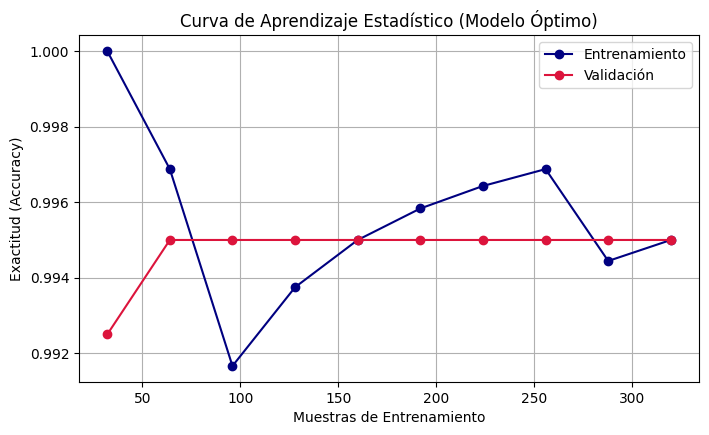

In [11]:
# 1. Verificación mediante GridSearchCV
param_grid = {'gamma': param_range, 'C': [1.0]}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_val, y_train_val)

print(f"Mejor gamma hallado por GridSearchCV: {grid_search.best_params_['gamma']:.4f}")

# 2. Generación de las Curvas de Aprendizaje Estadístico
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    grid_search.best_estimator_, X_train_val, y_train_val,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

plt.figure(figsize=(8, 4.5))
plt.plot(train_sizes, np.mean(train_scores_lc, axis=1), 'o-', color="navy", label="Entrenamiento")
plt.plot(train_sizes, np.mean(val_scores_lc, axis=1), 'o-', color="crimson", label="Validación")
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("Exactitud (Accuracy)")
plt.title("Curva de Aprendizaje Estadístico (Modelo Óptimo)")
plt.legend()
plt.grid(True)
plt.show()

Ambas curvas convergen a un valor alto de exactitud a medida que aumenta el tamaño de la muestra de entrenamiento. La convergencia con brecha pequeña entre el score de entrenamiento y validación confirma un modelo balanceado sin sesgo ni varianza excesivos.

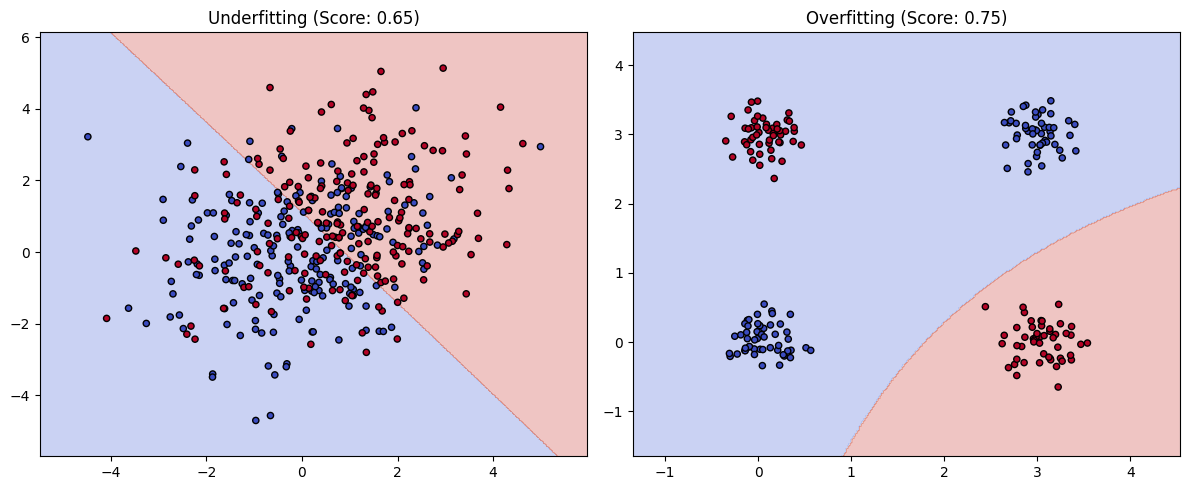

In [12]:
np.random.seed(42)

# Caso 1: Dataset para Underfitting (Alta varianza / Solapamiento de medias)
mean1, mean2 = [0, 0], [0.8, 0.8]
cov_under = [[2.5, 0.5], [0.5, 2.5]]

X_under1 = np.random.multivariate_normal(mean1, cov_under, 200)
X_under2 = np.random.multivariate_normal(mean2, cov_under, 200)
X_under = np.vstack((X_under1, X_under2))
y_under = np.array([0]*200 + [1]*200)

# Caso 2: Dataset para Overfitting (Estructura compleja multimodal y aislada)
cov_over = [[0.05, 0], [0, 0.05]]
cluster_a = np.random.multivariate_normal([0, 0], cov_over, 50)
cluster_b = np.random.multivariate_normal([3, 3], cov_over, 50)
cluster_c = np.random.multivariate_normal([0, 3], cov_over, 50) # Ruido interpuesto
cluster_d = np.random.multivariate_normal([3, 0], cov_over, 50)

X_over = np.vstack((cluster_a, cluster_b, cluster_c, cluster_d))
y_over = np.array([0]*100 + [1]*100)

# Visualización gráfica de fronteras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_boundary(model, X, y, ax, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(title)

# Modelo ajustado en datos de Underfitting
clf_under = SVC(kernel='rbf', gamma=best_gamma, C=1.0).fit(X_under, y_under)
plot_boundary(clf_under, X_under, y_under, axes[0], f"Underfitting (Score: {clf_under.score(X_under, y_under):.2f})")

# Modelo ajustado en datos de Overfitting
clf_over = SVC(kernel='rbf', gamma=best_gamma, C=1.0).fit(X_over, y_over)
plot_boundary(clf_over, X_over, y_over, axes[1], f"Overfitting (Score: {clf_over.score(X_over, y_over):.2f})")

plt.tight_layout()
plt.show()

Gráfico de Subajuste (Underfitting): Al modificar $\Sigma$ para incrementar la varianza y acercar las medias $\boldsymbol{\mu}$, las clases se solapan excesivamente. La frontera de decisión resulta insuficiente para discriminar el patrón subyacente.Gráfico de Sobreajuste (Overfitting): Al configurar centros dispersos con covarianza pequeña $\Sigma$, la rigidez estructural definida por $\gamma_{\text{óptimo}}$ intenta resolver límites inconexos, perdiendo generalización frente a perturbaciones espaciales.